# Experiment 4: Memory Capacity of Empirical Connectomes

In Experiments 1–3 we used randomly generated or optimised reservoir weight matrices. Here we ask: **what happens when the reservoir is an empirical brain connectome?**

We evaluate the Memory Capacity (MC) of four network variants derived from a chosen connectome:

1. **Structured** — the original empirical connectome as loaded
2. **Symmetrized structured** — $(W + W^T)/2$, eliminating all asymmetry
3. **Shuffled (null)** — degree-preserving rewired network via `bct.randmio_dir_connected`
4. **Symmetrized shuffled** — the same symmetrisation applied to the null network

For each variant we sweep the spectral radius $\alpha$ over a range and plot **MC vs $\alpha$** with error bars from 10 independent $W_{in}$ seeds. For the null variants, 10 independent realizations are generated and their mean ± std is shown as a single curve.

The weighted reciprocity and density of each variant are printed before the sweep, so students can connect the structural properties of the network to its computational behaviour.

## 0 · Setup

In [1]:
!pip install echoes netneurotools bctpy --quiet

In [2]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from echoes import ESNRegressor
from netneurotools.datasets import fetch_famous_gmat
import bct

warnings.filterwarnings('ignore')
print('All imports OK.')

All imports OK.


## 1 · Configuration

Choose your connectome from the list and adjust experiment parameters below.

In [3]:
# ── Connectome selection
# Available options:
# 'celegans', 'drosophila', 'human_struct_scale033', 'human_struct_scale060',
# 'human_struct_scale125', 'human_struct_scale250', 'human_struct_scale500',
# 'macaque_modha', 'mouse', 'rat'
CONNECTOME_NAME = 'human_struct_scale033'

# ── Data
SEQUENCE_LENGTH = 3000
NUM_DELAYS      = 40
TRAIN_FRACTION  = 0.7
N_TRANSIENT     = 100
NORMALIZE       = True    # normalise weights to [0, 1]

# ── Experiment
ALPHA_GRID    = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0, 1.1, 1.2, 1.3, 1.4]
N_WIN_SEEDS   = 10    # W_in seeds per alpha per network (error bars)
N_SHUFFLES    = 10    # null network realisations
GLOBAL_SEED   = 283

## 2 · Helper functions

In [4]:
# ── Structural measures
def compute_density(W):
    """Fraction of possible directed connections that are non-zero."""
    np.fill_diagonal(W, 0)
    N = W.shape[0]
    return float((W > 0).sum()) / (N * (N - 1))


def compute_reciprocity_weighted(adj_matrix):
    """Weighted reciprocity: fraction of total weight that is reciprocal."""
    adj = adj_matrix.copy()
    np.fill_diagonal(adj, 0)
    L  = adj.sum()
    W1 = np.minimum(adj, adj.T)
    return np.round(W1.sum() / L, 2) if L > 0 else 0.0


def print_network_stats(W, label):
    d = compute_density(W.copy())
    r = compute_reciprocity_weighted(W.copy())
    print(f'  {label:<30}  {W.shape[0]:4d}  {d:>15.3f}  {r:>20.3f}')
    return d, r


# ── Connectome loading
def load_connectome(name, normalize=True):
    W = fetch_famous_gmat(name)['conn'].astype(float)
    np.fill_diagonal(W, 0)
    if normalize:
        w_max = W.max()
        if w_max > 0:
            W = W / w_max
    return W


# ── Network variants
def symmetrize(W):
    """Algebraic symmetrisation: (W + W^T) / 2."""
    W_sym = (W + W.T) / 2.0
    np.fill_diagonal(W_sym, 0)
    return W_sym


def shuffle_network(W, n_iter=10, seed=None):
    """One degree-preserving rewired null network via bct.randmio_dir_connected."""
    if seed is not None:
        np.random.seed(seed)
    W_null, _ = bct.randmio_dir_connected(W.copy(), n_iter)
    np.fill_diagonal(W_null, 0)
    return W_null


# ── Data generation
def generate_mc_data(seq_len, num_delays, seed=None):
    rng = np.random.default_rng(seed)
    u   = rng.standard_normal(seq_len)
    y   = np.zeros((seq_len, num_delays))
    for k in range(num_delays):
        y[k + 1:, k] = u[:seq_len - k - 1]
    return u.reshape(-1, 1), y


# ── MC metric
def memory_capacity(y_true, y_pred):
    """Sum of squared Pearson r across lags (transient already removed)."""
    r2_per_lag = np.array([
        pearsonr(y_true[:, k], y_pred[:, k])[0] ** 2
        for k in range(y_true.shape[1])
    ])
    return float(r2_per_lag.sum())


# ── Single ESN evaluation
def evaluate_mc_single(W, alpha, win_seed, data_seed):
    """Evaluate MC for one network, one alpha, one W_in seed."""
    X, y = generate_mc_data(SEQUENCE_LENGTH, NUM_DELAYS, seed=data_seed)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=TRAIN_FRACTION, shuffle=False
    )

    rng = np.random.default_rng(win_seed)
    W_in = rng.uniform(-0.05, 0.05, size=(W.shape[0], 1))

    esn = ESNRegressor(
        n_reservoir       = W.shape[0],
        spectral_radius   = float(alpha),
        W                 = W.astype(float),
        W_in              = W_in,
        input_scaling     = None,
        bias              = 0.0,
        noise             = 1e-5,
        fit_only_states   = True,
        n_transient       = N_TRANSIENT,
        regression_method = 'ridge',
        ridge_alpha       = 1e-10,
        random_state      = int(win_seed),
        store_states_pred  = False,
        store_states_train = False,
    )
    try:
        esn.fit(X_train, y_train)
        y_pred = esn.predict(X_test)
        if not np.isfinite(y_pred).all():
            return np.nan
        t = N_TRANSIENT
        return memory_capacity(y_test[t:], y_pred[t:])
    except Exception:
        return np.nan


def evaluate_mc_over_alpha(W, alpha_grid, n_seeds, seed_offset=0):
    """
    Sweep alpha_grid for one network.

    Returns
    -------
    means : ndarray (len(alpha_grid),)
    stds  : ndarray (len(alpha_grid),)
    """
    means, stds = [], []
    for alpha in alpha_grid:
        scores = [
            evaluate_mc_single(
                W, alpha,
                win_seed  = GLOBAL_SEED + seed_offset + s,
                data_seed = GLOBAL_SEED + seed_offset + s + 500
            )
            for s in range(n_seeds)
        ]
        valid = [v for v in scores if np.isfinite(v)]
        means.append(np.mean(valid) if valid else np.nan)
        stds.append(np.std(valid)   if valid else np.nan)
    return np.array(means), np.array(stds)

## 3 · Load connectome and build four network variants

In [5]:
print(f'Loading {CONNECTOME_NAME} connectome...')
W_struct = load_connectome(CONNECTOME_NAME, normalize=NORMALIZE)

# ── Symmetrized structured
W_struct_sym = symmetrize(W_struct)

# ── Null networks (N_SHUFFLES realisations)
print(f'Generating {N_SHUFFLES} null network realizations...')
null_networks     = []
null_sym_networks = []
for s in range(N_SHUFFLES):
    W_null = shuffle_network(W_struct, seed=GLOBAL_SEED + s)
    null_networks.append(W_null)
    null_sym_networks.append(symmetrize(W_null))
    print(f'  Null {s+1}/{N_SHUFFLES} done')

# ── Print structural properties of all four variants
print('\n' + '='*80)
print(f'  {"Network":<30}  {"N":>4}  {"density":>15}  {"strength reciprocity":>20}')
print('-'*80)
d_s,  r_s  = print_network_stats(W_struct.copy(),     'Structured')
d_ss, r_ss = print_network_stats(W_struct_sym.copy(),  'Symmetrized structured')

# For null variants: report mean ± std across realisations
null_d  = [compute_density(W.copy())              for W in null_networks]
null_r  = [compute_reciprocity_weighted(W.copy()) for W in null_networks]
null_sd = [compute_density(W.copy())              for W in null_sym_networks]
null_sr = [compute_reciprocity_weighted(W.copy()) for W in null_sym_networks]

print(f'  {"Shuffled (null)":<30}  {W_struct.shape[0]:4d}  '
      f'{f"{np.mean(null_d):.3f}±{np.std(null_d):.3f}":>15}  '
      f'{f"{np.mean(null_r):.3f}±{np.std(null_r):.3f}":>20}')
print(f'  {"Symmetrized shuffled":<30}  {W_struct.shape[0]:4d}  '
      f'{f"{np.mean(null_sd):.3f}±{np.std(null_sd):.3f}":>15}  '
      f'{f"{np.mean(null_sr):.3f}±{np.std(null_sr):.3f}":>20}')
print('='*80)
print(f'\nNote: symmetrization (W+WT)/2 preserves density by construction.')

Loading human_struct_scale033 connectome...
Please cite the following papers if you are using this function:
  [primary]:
    
  [celegans]:
    Lav R Varshney, Beth L Chen, Eric Paniagua, David H Hall, and Dmitri B Chklovskii. Structural properties of the caenorhabditis elegans neuronal network. PLoS computational biology, 7(2):e1001066, 2011.
  [drosophila]:
    Ann-Shyn Chiang, Chih-Yung Lin, Chao-Chun Chuang, Hsiu-Ming Chang, Chang-Huain Hsieh, Chang-Wei Yeh, Chi-Tin Shih, Jian-Jheng Wu, Guo-Tzau Wang, Yung-Chang Chen, and others. Three-dimensional reconstruction of brain-wide wiring networks in drosophila at single-cell resolution. Current biology, 21(1):1–11, 2011.
  [human]:
    Alessandra Griffa, Yasser Alemán-Gómez, and Patric Hagmann. Structural and functional connectome from 70 young healthy adults [data set]. Zenodo, 2019.
  [macaque_markov]:
    Nikola T Markov, Maria Ercsey-Ravasz, Camille Lamy, Ana Rita Ribeiro Gomes, Loïc Magrou, Pierre Misery, Pascale Giroud, Pascal Ba

## 4 · MC vs alpha sweep

For each of the four network variants we sweep `ALPHA_GRID` and compute mean ± std MC over `N_WIN_SEEDS` independent $W_{in}$ seeds. For the null variants, we additionally average across `N_SHUFFLES` realisations.

In [6]:
alphas = np.array(ALPHA_GRID)

# ── 1. Structured
print('Sweeping alpha — Structured network...')
mc_s_mean, mc_s_std = evaluate_mc_over_alpha(
    W_struct, alphas, N_WIN_SEEDS, seed_offset=0
)
print('  done.')

# ── 2. Symmetrised structured
print('Sweeping alpha — Symmetrised structured...')
mc_ss_mean, mc_ss_std = evaluate_mc_over_alpha(
    W_struct_sym, alphas, N_WIN_SEEDS, seed_offset=100
)
print('  done.')

# ── 3. Null networks — sweep each realisation, then average
print(f'Sweeping alpha — {N_SHUFFLES} null realizations...')
null_mc_curves = []
for s, W_null in enumerate(null_networks):
    print(f'  Null {s+1}/{N_SHUFFLES}')
    m, _ = evaluate_mc_over_alpha(
        W_null, alphas, N_WIN_SEEDS, seed_offset=200 + s * 50
    )
    null_mc_curves.append(m)
null_mc_curves  = np.array(null_mc_curves)     # (N_SHUFFLES, len(alphas))
mc_n_mean = np.nanmean(null_mc_curves, axis=0)
mc_n_std  = np.nanstd(null_mc_curves,  axis=0)
print('  done.')

# ── 4. Symmetrised null — sweep each realisation, then average
print(f'Sweeping alpha — {N_SHUFFLES} symmetrised null realizations...')
null_sym_mc_curves = []
for s, W_null_sym in enumerate(null_sym_networks):
    print(f'  Sym-Null {s+1}/{N_SHUFFLES}')
    m, _ = evaluate_mc_over_alpha(
        W_null_sym, alphas, N_WIN_SEEDS, seed_offset=700 + s * 50
    )
    null_sym_mc_curves.append(m)
null_sym_mc_curves = np.array(null_sym_mc_curves)
mc_ns_mean = np.nanmean(null_sym_mc_curves, axis=0)
mc_ns_std  = np.nanstd(null_sym_mc_curves,  axis=0)
print('  done.')

print('\nAll sweeps complete.')

Sweeping alpha — Structured network...
  done.
Sweeping alpha — Symmetrised structured...
  done.
Sweeping alpha — 10 null realizations...
  Null 1/10
  Null 2/10
  Null 3/10
  Null 4/10
  Null 5/10
  Null 6/10
  Null 7/10
  Null 8/10
  Null 9/10
  Null 10/10
  done.
Sweeping alpha — 10 symmetrised null realizations...
  Sym-Null 1/10
  Sym-Null 2/10
  Sym-Null 3/10
  Sym-Null 4/10
  Sym-Null 5/10
  Sym-Null 6/10
  Sym-Null 7/10
  Sym-Null 8/10
  Sym-Null 9/10
  Sym-Null 10/10
  done.

All sweeps complete.


## 5 · Visualization

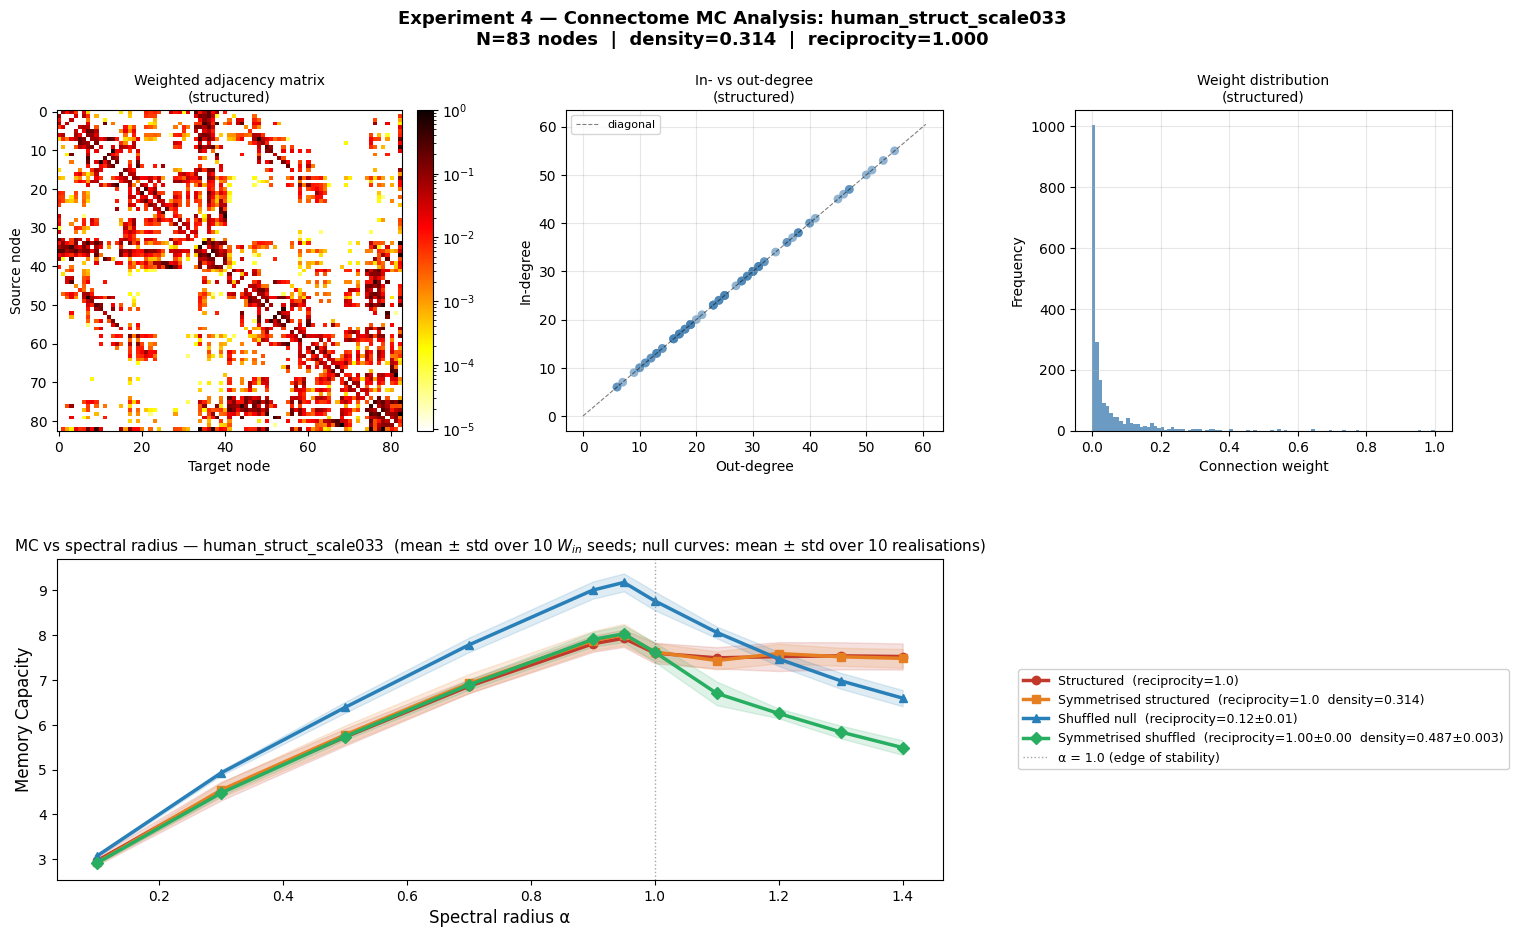

Figure saved to human_struct_scale033_experiment4_mc_alpha.png


In [7]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])   # adjacency matrix
ax1 = fig.add_subplot(gs[0, 1])   # in vs out degree
ax2 = fig.add_subplot(gs[0, 2])   # weight distribution
ax3 = fig.add_subplot(gs[1, :2])  # MC vs alpha — two thirds
ax_leg = fig.add_subplot(gs[1, 2])  # legend panel — one third


fig.suptitle(
    f'Experiment 4 — Connectome MC Analysis: {CONNECTOME_NAME.lower()}\n'
    f'N={W_struct.shape[0]} nodes  |  '
    f'density={d_s:.3f}  |  reciprocity={r_s:.3f}',
    fontsize=13, fontweight='bold'
)

# ── Panel 0: adjacency matrix
W_pos = W_struct[W_struct > 0]
if len(W_pos) > 0:
    W_display = np.where(W_struct > 0, W_struct, np.nan)
    im = ax0.imshow(W_display, cmap='hot_r',
                    norm=LogNorm(vmin=W_pos.min(), vmax=W_pos.max()),
                    aspect='auto')
    plt.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)
ax0.set_title('Weighted adjacency matrix\n(structured)', fontsize=10)
ax0.set_xlabel('Target node')
ax0.set_ylabel('Source node')

# ── Panel 1: in-degree vs out-degree
W_bin   = (W_struct > 0).astype(float)
in_deg  = W_bin.sum(axis=0)
out_deg = W_bin.sum(axis=1)
ax1.scatter(out_deg, in_deg, alpha=0.6, color='steelblue',
            edgecolors='none', s=40)
lim_max = max(in_deg.max(), out_deg.max()) * 1.1
ax1.plot([0, lim_max], [0, lim_max], 'k--', lw=0.8, alpha=0.5, label='diagonal')
ax1.set_xlabel('Out-degree')
ax1.set_ylabel('In-degree')
ax1.set_title('In- vs out-degree\n(structured)', fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Panel 2: weight distribution
ax2.hist(W_struct[W_struct > 0], bins=100, color='steelblue',
         edgecolor='none', alpha=0.8)
ax2.set_xlabel('Connection weight')
ax2.set_ylabel('Frequency')
ax2.set_title('Weight distribution\n(structured)', fontsize=10)
ax2.grid(True, alpha=0.3)

# ── Panel 3: MC vs alpha — all four variants
colors = {
    'struct'    : '#c0392b',   # dark red
    'struct_sym': '#e67e22',   # amber
    'null'      : '#2980b9',   # medium blue
    'null_sym'  : '#27ae60',   # medium green
}


ax3.plot(alphas, mc_s_mean,  color=colors['struct'],    lw=2.5, marker='o',
         markersize=6, label=f'Structured  (reciprocity={r_s})')
ax3.fill_between(alphas,
                 mc_s_mean - mc_s_std,
                 mc_s_mean + mc_s_std,
                 color=colors['struct'], alpha=0.15)

ax3.plot(alphas, mc_ss_mean, color=colors['struct_sym'], lw=2.5, marker='s',
         markersize=6,
         label=f'Symmetrised structured  (reciprocity={r_ss}  density={d_ss:.3f})')
ax3.fill_between(alphas,
                 mc_ss_mean - mc_ss_std,
                 mc_ss_mean + mc_ss_std,
                 color=colors['struct_sym'], alpha=0.15)

ax3.plot(alphas, mc_n_mean,  color=colors['null'],       lw=2.5, marker='^',
         markersize=6,
         label=f'Shuffled null  (reciprocity={np.mean(null_r):.2f}±{np.std(null_r):.2f})')
ax3.fill_between(alphas,
                 mc_n_mean - mc_n_std,
                 mc_n_mean + mc_n_std,
                 color=colors['null'], alpha=0.15)

ax3.plot(alphas, mc_ns_mean, color=colors['null_sym'],   lw=2.5, marker='D',
         markersize=6,
         label=f'Symmetrised shuffled  (reciprocity={np.mean(null_sr):.2f}±{np.std(null_sr):.2f}  density={np.mean(null_sd):.3f}±{np.std(null_sd):.3f})')
ax3.fill_between(alphas,
                 mc_ns_mean - mc_ns_std,
                 mc_ns_mean + mc_ns_std,
                 color=colors['null_sym'], alpha=0.15)

ax3.axvline(1.0, color='gray', lw=1.0, linestyle=':', alpha=0.7,
            label='α = 1.0 (edge of stability)')
ax3.set_xlabel('Spectral radius α', fontsize=12)
ax3.set_ylabel('Memory Capacity', fontsize=12)
ax3.set_title(
    f'MC vs spectral radius — {CONNECTOME_NAME.lower()}  '
    f'(mean ± std over {N_WIN_SEEDS} $W_{{in}}$ seeds; '
    f'null curves: mean ± std over {N_SHUFFLES} realisations)',
    fontsize=11
)
handles, labels = ax3.get_legend_handles_labels()
ax_leg.legend(handles, labels, loc='center', fontsize=9,
              frameon=True, framealpha=0.9)
ax_leg.axis('off')   # hide axes, show only the legend box

plt.savefig(f'{CONNECTOME_NAME}_experiment4_mc_alpha.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {CONNECTOME_NAME}_experiment4_mc_alpha.png')

## 6 · Summary table

In [8]:
best_s  = alphas[np.nanargmax(mc_s_mean)]
best_ss = alphas[np.nanargmax(mc_ss_mean)]
best_n  = alphas[np.nanargmax(mc_n_mean)]
best_ns = alphas[np.nanargmax(mc_ns_mean)]

print('\n' + '='*75)
print(f'  {"Network":<28}  {"Best α":>6}  {"Peak MC (mean±std)":>22}  {"Reciprocity":>11}')
print('-'*75)
print(f'  {"Structured":<28}  {best_s:>6.2f}  '
      f'{np.nanmax(mc_s_mean):>8.4f} ± {mc_s_std[np.nanargmax(mc_s_mean)]:>7.4f}  '
      f'{r_s:>11.3f}')
print(f'  {"Symmetrised structured":<28}  {best_ss:>6.2f}  '
      f'{np.nanmax(mc_ss_mean):>8.4f} ± {mc_ss_std[np.nanargmax(mc_ss_mean)]:>7.4f}  '
      f'{r_ss:>11.3f}')
print(f'  {"Shuffled null":<28}  {best_n:>6.2f}  '
      f'{np.nanmax(mc_n_mean):>8.4f} ± {mc_n_std[np.nanargmax(mc_n_mean)]:>7.4f}  '
      f'{np.mean(null_r):>11.3f}')
print(f'  {"Symmetrised shuffled":<28}  {best_ns:>6.2f}  '
      f'{np.nanmax(mc_ns_mean):>8.4f} ± {mc_ns_std[np.nanargmax(mc_ns_mean)]:>7.4f}  '
      f'{np.mean(null_sr):>11.3f}')
print('='*75)


  Network                       Best α      Peak MC (mean±std)  Reciprocity
---------------------------------------------------------------------------
  Structured                      0.95    7.9311 ±  0.1926        1.000
  Symmetrised structured          0.95    8.0118 ±  0.2394        1.000
  Shuffled null                   0.95    9.1773 ±  0.1997        0.118
  Symmetrised shuffled            0.95    8.0296 ±  0.1843        1.000


## 7 · Why controlling density and reciprocity matters for a fair comparison

The four network variants analyzed above differ not only in their wiring pattern but potentially in two fundamental structural properties: **connection density** and **weighted reciprocity**. This matters because both properties independently influence Memory Capacity:

- **Density** determines how many connections are available to propagate and transform the input signal.

- **Reciprocity** controls the degree of asymmetry in the flow of information. Highly reciprocal networks tend to form closed loops that can destabilise dynamics and reduce the diversity of reservoir states — directly limiting memory capacity, as visible in the curves above.

When comparing a structured connectome to a null model, or a symmetrized variant to its asymmetric counterpart, any observed difference in MC could in principle be explained by an unintended change in density or reciprocity rather than by the specific wiring pattern of interest. A fair comparison therefore requires that these properties be **explicitly controlled**.

Symmetrization via $(W + W^T)/2$ does not necessarily preserve density by construction, and it does not allow graded control of reciprocity. For a rigorous investigation, one needs algorithms that can steer reciprocity continuously while holding density (or total weight) fixed.

This question is directly addressed in the following works from our group:



**Hadaeghi, F., Fakhar, K., & Hilgetag, C. C. (2026).** Controlling reciprocity in binary and weighted networks: A novel density-conserving approach. *Chaos*, 36(2), 023116. https://doi.org/10.1063/5.0304136

We introduce Network Reciprocity Control (NRC) algorithms that steer the asymmetry–reciprocity balance in binary and weighted networks while preserving edge density and cumulative edge weight. Applied to synthetic benchmarks and empirical connectomes across species, the algorithms reveal how graded reciprocity shapes spectral properties, community structure, and — directly relevant here — memory capacity in the reservoir computing framework.



**Hadaeghi, F., Fakhar, K., Khajehnejad, M., & Hilgetag, C. C. (2025).** A computational perspective on the no-strong-loops principle in brain networks. *bioRxiv*, 2025.09.24.678310. https://www.biorxiv.org/content/10.1101/2025.09.24.678310

Cerebral cortical networks systematically avoid strong reciprocal projections — the "no-strong-loops" principle. Using reservoir computing models, we show that connectivity asymmetry supports high working-memory capacity, whereas increasing reciprocity reduces both memory capacity and representational diversity. These results are validated on directed macaque and marmoset connectomes and suggest a biologically-inspired design principle for artificial neural systems.